1. Ứng dụng nén ảnh

In [12]:
#Khai báo thư viện sử dụng trong bài
from skimage import io
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as image
from IPython.display import Image, display

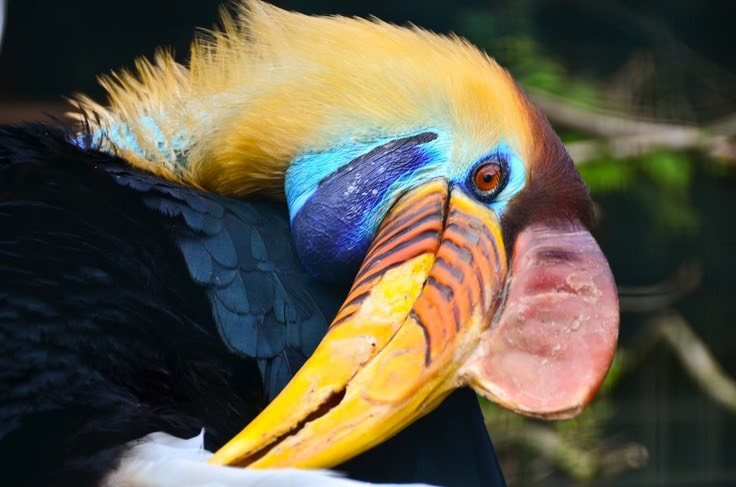

Dữ liệu ảnh trước khi reshape: (487, 736, 3)
Số chiều của dữ liệu hình ảnh:  (358432, 3)
Tổng số điểm ảnh là:  358432
Mỗi điểm ảnh có số chiều =  3


In [13]:
#Đọc dữ liệu hình ảnh
path_img = 'bird.jpg'
display(Image(path_img, width=250, unconfined=True))
img = io.imread(path_img)
print("Dữ liệu ảnh trước khi reshape:", img.shape)
img_shape = img.shape # 128x128x3
data_img = (img / 255.0).reshape(-1,img.shape[2]) # chuyển ma trận 128x128x3 về␣,→mảng 2 chiều, giữ lại chiều .shape[2]
print("Số chiều của dữ liệu hình ảnh: ", data_img.shape)
print("Tổng số điểm ảnh là: ", data_img.shape[0])
print("Mỗi điểm ảnh có số chiều = ", data_img.shape[1])

In [14]:
#Xây dựng mô hình nén ảnh
n_color = 10
k_mean_model = KMeans(n_clusters=n_color)

In [15]:
#huấn luyện mô hình
k_mean_model.fit(data_img)

KMeans(n_clusters=10)

In [16]:
# Hiển thị một số thông tin đã học của mô hình
print("Số chiều của tâm cụm: ", k_mean_model.cluster_centers_.shape)
print(k_mean_model.cluster_centers_)
print(k_mean_model.labels_[0:20])


Số chiều của tâm cụm:  (10, 3)
[[0.94972042 0.73174371 0.24628579]
 [0.13801669 0.16482366 0.14675492]
 [0.57212701 0.4471692  0.31082874]
 [0.73016373 0.85661371 0.88856045]
 [0.15309775 0.24960041 0.39901929]
 [0.37465309 0.54789822 0.75979401]
 [0.78205608 0.59541617 0.5127803 ]
 [0.34179481 0.30820883 0.16604484]
 [0.92262417 0.78991796 0.55250428]
 [0.04218589 0.0740467  0.08830596]]
[5 5 5 4 4 1 1 1 9 9 9 9 9 9 9 9 9 9 9 9]


In [17]:
# k_mean_model.labels_: chứa nhãn của tất cả các điểm ảnh
# k_mean_model.cluster_centers_: chứa các tâm cụm.
#new_arr = arr1[index]
img128=k_mean_model.cluster_centers_[k_mean_model.labels_]
print(img128.shape)
# chuẩn hoá lại kích thước ảnh theo chiều dài, rộng ban đầu
img128=np.reshape(img128, img_shape)
print(img128.shape)
image.imsave('img128.png', img128)

(358432, 3)
(487, 736, 3)


In [18]:
# hiển thị kích thước hình ảnh trước và sau khi nén
import os
print('Size of compressed image: ' + str(os.path.getsize('img128.png')) + ' KB')
print('Size of original image: ' + str(os.path.getsize('bird.jpg')) + ' KB')

Size of compressed image: 58619 KB
Size of original image: 87782 KB


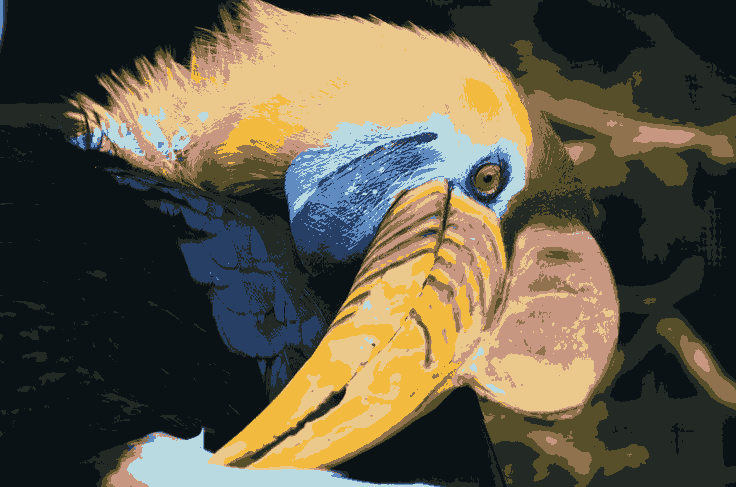

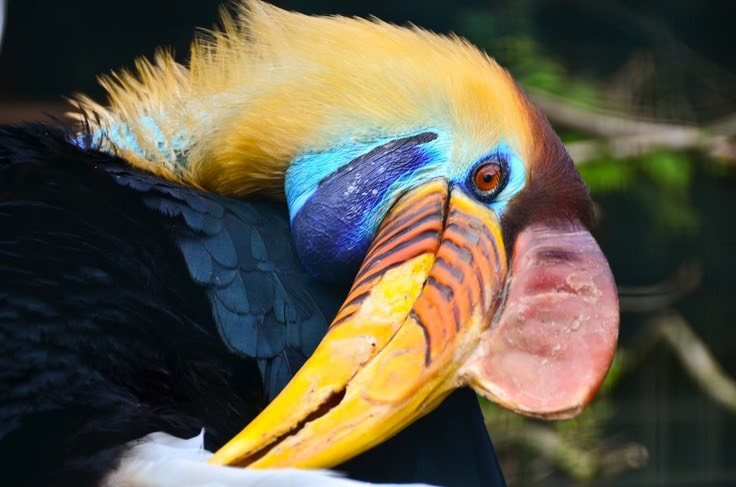

In [19]:
from IPython.display import Image, display
#Save image
display(Image('img128.png', width=250, unconfined=True))
display(Image(path_img, width=250, unconfined=True))


2. Bài tập 

nén ảnh thành ảnh có số màu < 5

In [20]:
# Nén hình ảnh
for i in range(1, 5):

    n_color = i #Số lượng màu nén

    k_mean_model = KMeans(n_clusters=n_color)

    k_mean_model.fit(data_img)

    img =k_mean_model.cluster_centers_[k_mean_model.labels_]

    img =np.reshape(img, img_shape) #Đặt lại kích thước hình ảnh

    image.imsave('img' + str(i) + '.png', img) #Lưu hình ảnh
    

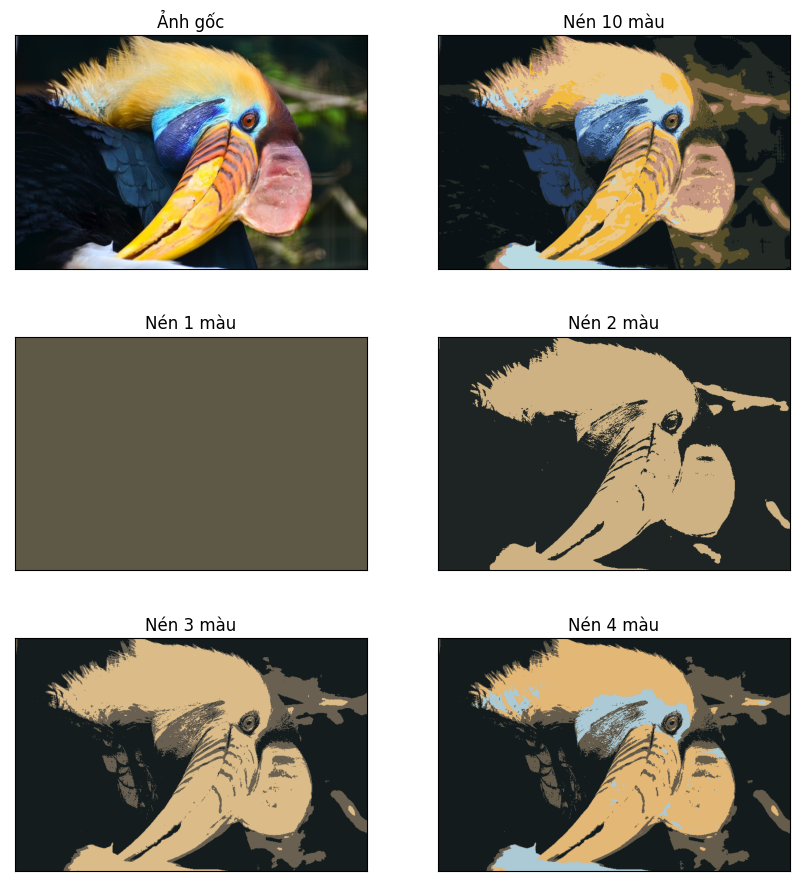

In [21]:
from PIL import Image

plt.figure(figsize= (10, 15))

plt.subplot(421)
img = Image.open('bird.jpg')
plt.imshow(img),plt.title('Ảnh gốc')
plt.xticks([]), plt.yticks([])

plt.subplot(422)
img = Image.open('img128.png')
plt.imshow(img), plt.title('Nén 10 màu')
plt.xticks([]), plt.yticks([])

for i in range (1, 5):
    plt.subplot(4, 2, i+2)
    img = Image.open('img' + str(i) + '.png')
    plt.imshow(img), plt.title('Nén ' + str(i) + ' màu')
    plt.xticks([]), plt.yticks([])

plt.show()


In [23]:
# hiển thị kích thước hình ảnh trước và sau khi nén
import os
print('Size of original image: ' + str(os.path.getsize('bird.jpg')) + ' KB')

for i in range (1, 5):
    print('Size of compressed into ' + str(i) + ' colors image: ' + str(os.path.getsize('img' + str(i) + '.png')) + ' KB')

Size of original image: 87782 KB
Size of compressed into 1 colors image: 2616 KB
Size of compressed into 2 colors image: 13713 KB
Size of compressed into 3 colors image: 24327 KB
Size of compressed into 4 colors image: 27374 KB
